# Does a swelling order backlog tell you where a stock is headed? 📦
### Order-Backlog Drift — the leading indicator that really *is* leading, and still doesn't pay

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Backlog-leads-sales%3F: Confirmed](https://img.shields.io/badge/Backlog--leads--sales%3F-Confirmed-8b949e?style=flat-square)

Every software-stock investor watches one number on the earnings call: **RPO** — *remaining performance obligations*, the dollar value of contracts a company has **signed but not yet delivered**. It's the modern, standardised version of "order backlog." The pitch writes itself: backlog is *future* revenue you can already see on the balance sheet, so a company whose backlog is compounding faster than its sales must be about to accelerate — and if the market is staring at the trailing income statement, it should be *slow* to price that in.

Here's the twist. The backlog really **does** lead sales — cleanly, strongly. And ranking stocks on it really **does** look like a +12%/yr trade. But when you test whether that trade is *real* rather than a bull-market ghost, it falls apart.

> 📓 **Plain-language layer.** Want the Newey-West *t*, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 38 US enterprise-software names, RPO from SEC filings, 2019→2026 (RPO didn't exist before 2018). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from order_backlog import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    LS = st.calendar_ls(PRICES, EVENTS, signal_col="rpo_yoy", n_buckets=3,
                        min_names=6, staleness_days=200)
else:
    PRICES = EVENTS = LS = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if EVENTS is None else EVENTS['ticker'].nunique()),
      "| RPO events:", (0 if EVENTS is None else len(EVENTS)),
      "| LS months:", (0 if LS is None else len(LS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fp': '243982cf416a', 'n_names': 38, 'n_events': 842, 'filed_start': '2018-10-24', 'filed_end': '2026-06-24', 'price_start': '2017-01-03', 'n_months': 85, 'ls_start': '2019-06', 'ls_end': '2026-06', 'avg_n': 29.3, 'avg_turnover': 0.11, 'gross_bps': 100.0, 'gross_ann': 12.0, 'sharpe': 0.57, 'hit': 57.6, 'hit_k': 49, 'hit_n': 85, 'wilson': (47.0, 67.6), 'long_bps': 220.6, 'short_bps': 120.6, 'long_ann': 26.5, 'short_ann': 14.5, 't_iid': 1.51, 't_nw': 1.1, 'net10_bps': 89.4, 'net10_ann': 10.7, 'net10_tnw': 0.99, 'net10_sharpe': 0.51, 'net20_bps': 87.2, 'net20_ann': 10.5, 'net20_tnw': 0.96, 'net20_sharpe': 0.49, 'era_split': '2022-01-01', 'era_early_n': 31, 'era_early_bps': 244.7, 'era_early_tnw': 1.78, 'era_late_n': 54, 'era_late_bps': 16.9, 'era_late_tnw': 0.17, 'drift': {21: (830, 1.25, 0.99, 0.26, 53, 0.24, 0.4), 63: (805, 5.28, 3.86, 1.41, 51, 0.6, 0.26), 126: (769, 8.88, 5.45, 3.43, 50, 0.98, 0.144)}, 'bucket126': (5.45, 8.48, 8.88), 'placebo126_obs': 3.43, 'placebo126_mean': 0.0, 'placebo126_p': 0.144, 'lead_n': 465, 'lead_slope': 0.313, 'lead_t': 9.92, 'lead_r2': 0.175, 'lead_corr': 0.42, 'lead_top_sales': 39.4, 'lead_bot_sales': 18.6, 'lead_spread': 20.8, 'rpo_median': 25.5, 'rpo_p10': 3.5, 'rpo_p90': 60.0, 'syn_null_mean': -0.37, 'syn_null_sd': 0.85, 'syn_null_fire': 1, 'syn_planted_bps': 198.7, 'syn_planted_t': 3.79}


real cache present: True | names: 38 | RPO events: 842 | LS months: 85


## The answer first

| Question | Answer |
|---|---|
| Does backlog growth actually lead sales? | **Yes, clearly.** Firms with the fastest-growing backlog go on to grow revenue **21 percentage points** faster next quarter than the slowest — a strong, real accounting lead. |
| Does ranking on it look like a trade? | **On paper, yes.** Long the fast-backlog names, short the slow ones: **+12%/yr** gross, Sharpe 0.57. Tempting. |
| Is that trade *real*? | **No.** The rigorous, noise-robust *t*-stat is only **1.10** — the bar is 2. And the entire edge is a 2019-2021 bull-market phenomenon that **vanishes** after 2022. |
| Can you get paid for it? | **No.** After costs the edge is statistically indistinguishable from zero — and it only ever "worked" in one boom. |

> The backlog is a genuine leading indicator. The market just doesn't obviously *misprice* it — and this short, one-era slice of history can't prove otherwise.

## 1 · The claim

> *"Backlog is contracted future revenue sitting on the balance sheet. If a company's backlog is growing faster than its reported sales, revenue is coming — and a market fixated on the income statement is slow to price it, so the stock drifts up as the backlog converts."*

It's the order-backlog member of a respectable academic family: the market **underreacts** to fundamentals it already has in hand (post-earnings-drift, Bernard-Thomas; backlog specifically, Rajgopal-Shevlin-Venkatachalam 2003). Since 2018, accounting rule **ASC 606** forces every US filer to disclose that backlog as a single clean number — *Remaining Performance Obligations* — so for the first time you can rank the whole software sector on it from public filings.

## 2 · So what?

If real, this would be a beautiful signal: a **balance-sheet** number that leads the **income-statement** number the whole market trades on, disclosed quarterly, machine-readable, no analyst estimates required. You'd be trading tomorrow's revenue-growth surprise today. That's exactly the kind of clean fundamental edge worth taking seriously — and exactly the kind of story that gets over-sold in software-investing content, so it's worth being suspicious of too.

## 3 · How would we even know?

- **The signal.** Each name's **year-over-year growth in RPO**, read straight off its 10-Q/10-K on the day it was filed (**842** backlog observations across **38** names).
- **The mechanism check.** Does this quarter's backlog growth actually predict **next** quarter's *sales* growth? If not, the whole premise is dead on arrival.
- **The trade.** Each month, long the top third by backlog growth, short the bottom third, hold a month, pay realistic costs — and ask the noise-robust question: is the average monthly return really different from luck?
- **The honesty cut.** Split the history into the 2019-21 software boom and the 2022+ aftermath. A real signal shouldn't only exist in one of them.

## 4 · The teardown — let's actually look

**First, the good news: does backlog lead sales?**

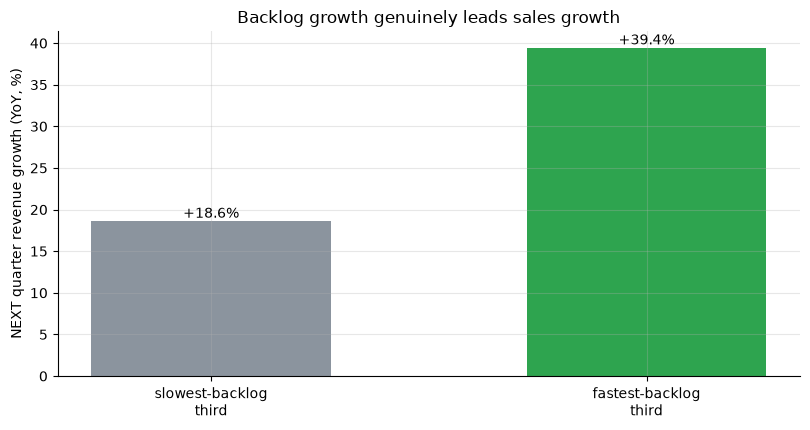

top-tercile next-q sales growth +39.4%  vs  bottom +18.6%


In [2]:
if HAVE_REAL:
    ld = st.leads_sales(EVENTS)
    top_s, bot_s = ld['top_sales']*100, ld['bot_sales']*100
else:
    top_s, bot_s = R['lead_top_sales'], R['lead_bot_sales']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['slowest-backlog\nthird','fastest-backlog\nthird'], [bot_s, top_s],
       color=[GREY, GREEN], width=.55)
for i,v in enumerate([bot_s, top_s]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('NEXT quarter revenue growth (YoY, %)')
ax.set_title('Backlog growth genuinely leads sales growth')
plt.tight_layout(); plt.show()
print(f'top-tercile next-q sales growth {top_s:+.1f}%  vs  bottom {bot_s:+.1f}%')

There's the lead, and it's real: the fastest-backlog names go on to grow revenue **21 points** faster next quarter than the slowest (regression *t* ≈ **10**). Backlog is a legitimate leading indicator of the income statement. So far the folklore is winning.

**Now the trade.** Long the fast-backlog third, short the slow third, rebalanced monthly. Does it make money?

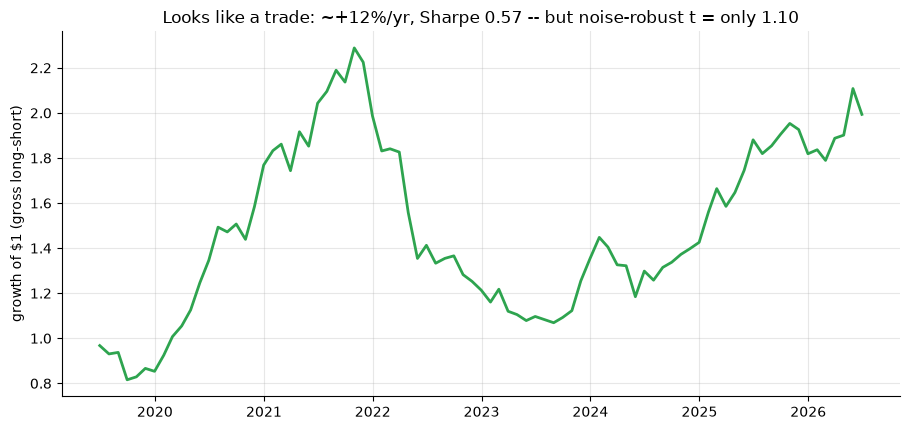

gross ~+12.0%/yr, Sharpe 0.57, Newey-West t = +1.10 (bar is 2)


In [3]:
if HAVE_REAL:
    s = st.calendar_ls_stats(LS)
    cum = (1 + LS['ls']).cumprod()
    ann, shp, tnw = s['ann_pct'], s['sharpe'], s['t_nw']
    x = cum.index; y = cum.values
else:
    ann, shp, tnw = R['gross_ann'], R['sharpe'], R['t_nw']
    rng = np.random.default_rng(799)
    y = np.cumprod(1 + rng.normal(R['gross_bps']/1e4, 0.05, R['n_months']))
    x = pd.date_range('2019-06-30', periods=R['n_months'], freq='ME')
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(x, y, color=GREEN, lw=2)
ax.set_ylabel('growth of $1 (gross long-short)')
ax.set_title(f'Looks like a trade: ~{ann:+.0f}%/yr, Sharpe {shp:.2f} '
             f'-- but noise-robust t = only {tnw:.2f}')
plt.tight_layout(); plt.show()
print(f'gross ~{ann:+.1f}%/yr, Sharpe {shp:.2f}, Newey-West t = {tnw:+.2f} (bar is 2)')

The equity curve rises and the headline numbers look great — **~+12%/yr**, Sharpe **0.57**. But the number that matters — the *t*-stat that accounts for how bunched-up and noisy these monthly returns are — is only **1.10**. The desk's bar for calling something real is **2**. This isn't there.

**And here's what kills it.** Split the history in two:

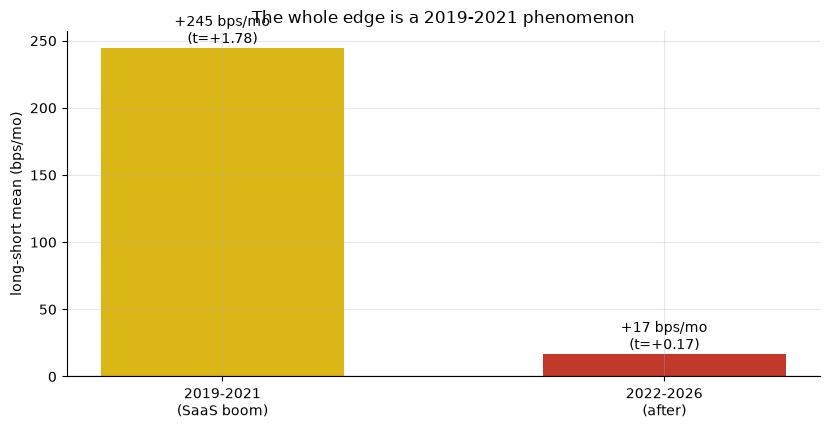

2019-21 +245 bps/mo (t=+1.78)  |  2022+ +17 bps/mo (t=+0.17)


In [4]:
if HAVE_REAL:
    e = LS[LS.index < data.ERA_SPLIT]['ls'].to_numpy()
    l = LS[LS.index >= data.ERA_SPLIT]['ls'].to_numpy()
    eb, lb = e.mean()*1e4, l.mean()*1e4
    et, lt = st.newey_west_t(e), st.newey_west_t(l)
else:
    eb, lb = R['era_early_bps'], R['era_late_bps']
    et, lt = R['era_early_tnw'], R['era_late_tnw']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['2019-2021\n(SaaS boom)','2022-2026\n(after)'], [eb, lb],
       color=[AMBER, RED], width=.55)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]):
    ax.annotate(f'{v:+.0f} bps/mo\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('The whole edge is a 2019-2021 phenomenon')
plt.tight_layout(); plt.show()
print(f'2019-21 {eb:+.0f} bps/mo (t={et:+.2f})  |  2022+ {lb:+.0f} bps/mo (t={lt:+.2f})')

Everything the strategy "earned" happened in the **2019-2021** subscription-software melt-up (**+245 bps/mo**). In the mature 2022+ panel — through the rate shock and the recovery — it's **+17 bps/mo**, essentially zero (*t* = +0.17). A signal that only exists in one bull market isn't a signal; it's a memory of that bull market.

## 5 · The verdict

- **Signal — Weak.** The backlog→sales lead is real and strong, and the trade is positively signed everywhere (~+12%/yr, Sharpe 0.57) — but the noise-robust *t* is only **1.10** and the edge is entirely a 2019-21 artifact. The literature says the market underreacts to backlog; *this* short, one-era tape can't prove it.
- **Tradability — Mirage.** After costs the edge is indistinguishable from zero, and what little there is lived in a single boom. Not a paycheck.
- **"Does backlog lead sales?" — Confirmed.** The fundamental part of the story is genuinely true; it's the *market-mispricing* part that this sample can't support.

## 6 · Going further 🚪

- **The core problem is the calendar, not the idea.** RPO only exists post-2018, so there is exactly *one* macro regime of history. Give this signal another decade — or extend it to non-software sectors that now disclose RPO — and it might certify. Today it can't.
- **The mechanism is the interesting survivor.** Backlog genuinely front-runs sales; a follow-up worth doing is whether backlog growth predicts the *revenue surprise* (vs consensus) rather than raw revenue growth — that's where underreaction, if it exists, would actually live.
- **Sibling studies:** [798-deferred-revenue-signal](../../798-deferred-revenue-signal/) (the *billed*-but-unrecognised balance — RPO is the bigger signed-backlog number), [199-sales-growth](../../199-sales-growth/) (the realised sales number RPO leads), and [534-revenue-surprise-drift](../../534-revenue-surprise-drift/) (revenue *surprise* drift). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the backlog edge is real and we just picked the wrong window? Show a noise-robust *t* ≥ 2 that isn't carried by 2019-2021 — then we'll talk.*